<a href="https://colab.research.google.com/github/nitin28061999/Glassdoor-salary-predictor/blob/main/FMCG_Sales_Insight_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
import os

os.listdir('/content')

['.config', 'FMCG_100K_DATASET.zip', 'sample_data']

In [9]:
import zipfile

zip_file_path = '/content/FMCG_100K_DATASET.zip'
csv_file_name = 'Indian FMCG Retail Sales  Customer  Inventory (2024).csv'

# Extract the specific CSV file from the ZIP archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract(csv_file_name, '/content/') # Extract to /content/

# Read the extracted CSV file into a DataFrame
df = pd.read_csv(f'/content/{csv_file_name}')

df.head()

,Invoice_ID,Invoice_Date,City,Store_Format,Category,Brand,Channel,Payment_Mode,Units,Cost_Price,Selling_Price,Revenue,Cost,Margin,Margin_%,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Customer_Age,Customer_Gender,Loyalty_Flag
0,58018430,2024-02-02 13:50:00,Kolkata,Super,Grocery,Nestle,Online,Wallet,2,148.999035,175.057209,350.114418,297.998070,52.116348,0.148855,154,31,11,20.0,M,1
1,48157952,2024-10-09 11:52:00,Hyderabad,Hyper,Home Care,PepsiCo,Offline,Wallet,1,80.626759,106.034197,106.034197,80.626759,25.407438,0.239616,130,24,5,26.0,F,1
2,23283831,2024-08-26 22:03:00,Chennai,Hyper,Snacks,PepsiCo,Online,Card,5,181.233170,208.980023,1044.900114,906.165848,138.734266,0.132773,270,44,8,27.0,F,0
3,53537460,2024-06-09 04:34:00,Bengaluru,Hyper,Beverages,Nestle,Omnichannel,Card,2,195.811402,260.879960,521.759920,391.622805,130.137115,0.249420,403,63,8,NaN,F,0
4,55348596,2024-06-07 01:13:00,Delhi,Super,Snacks,ITC,Offline,Card,3,23.571888,30.624472,91.873416,70.715665,21.157751,0.230292,366,40,9,60.0,F,1


In [10]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (100000, 21)

Columns:
['Invoice_ID', 'Invoice_Date', 'City', 'Store_Format', 'Category', 'Brand', 'Channel', 'Payment_Mode', 'Units', 'Cost_Price', 'Selling_Price', 'Revenue', 'Cost', 'Margin', 'Margin_%', 'Stock_On_Hand', 'Reorder_Level', 'Lead_Time_Days', 'Customer_Age', 'Customer_Gender', 'Loyalty_Flag']

Data types:
Invoice_ID           int64
Invoice_Date        object
City                object
Store_Format        object
Category            object
Brand               object
Channel             object
Payment_Mode        object
Units                int64
Cost_Price         float64
Selling_Price      float64
Revenue            float64
Cost               float64
Margin             float64
Margin_%           float64
Stock_On_Hand        int64
Reorder_Level        int64
Lead_Time_Days       int64
Customer_Age       float64
Customer_Gender     object
Loyalty_Flag         int64
dtype: object

Missing values:
Invoice_ID             0
Invoice_Date           0
City                  

In [11]:
df.shape
df.columns.tolist()
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Invoice_ID       100000 non-null  int64  
 1   Invoice_Date     100000 non-null  object 
 2   City             100000 non-null  object 
 3   Store_Format     100000 non-null  object 
 4   Category         100000 non-null  object 
 5   Brand            100000 non-null  object 
 6   Channel          100000 non-null  object 
 7   Payment_Mode     100000 non-null  object 
 8   Units            100000 non-null  int64  
 9   Cost_Price       100000 non-null  float64
 10  Selling_Price    100000 non-null  float64
 11  Revenue          100000 non-null  float64
 12  Cost             100000 non-null  float64
 13  Margin           100000 non-null  float64
 14  Margin_%         100000 non-null  float64
 15  Stock_On_Hand    100000 non-null  int64  
 16  Reorder_Level    100000 non-null  int64

,0
Invoice_ID,0
Invoice_Date,0
City,0
Store_Format,0
Category,0
Brand,0
Channel,0
Payment_Mode,0
Units,0
Cost_Price,0


In [12]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [13]:
# Check duplicate Invoice IDs
duplicate_invoices = df['Invoice_ID'].duplicated().sum()

print("Duplicate Invoice IDs:", duplicate_invoices)

Duplicate Invoice IDs: 62


In [14]:
# Convert Invoice_Date to datetime
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'], errors='coerce')

print(df['Invoice_Date'].dtype)

datetime64[ns]


In [15]:
print("Invalid dates:", df['Invoice_Date'].isna().sum())

Invalid dates: 0


In [16]:
print("Minimum date:", df['Invoice_Date'].min())
print("Maximum date:", df['Invoice_Date'].max())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2024-12-30 23:57:00


In [17]:
categorical_columns = [
    'City',
    'Store_Format',
    'Category',
    'Brand',
    'Channel',
    'Payment_Mode',
    'Customer_Gender'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- City ---
City
Kolkata      12681
Delhi        12649
Mumbai       12492
Chennai      12467
Hyderabad    12440
Ahmedabad    12436
Bengaluru    12432
Pune         12403
Name: count, dtype: int64

--- Store_Format ---
Store_Format
Hyper      33443
Express    33314
Super      33243
Name: count, dtype: int64

--- Category ---
Category
Fruits           12708
Home Care        12630
Beverages        12585
Snacks           12514
Vegetables       12472
Grocery          12412
Personal Care    12409
Dairy            12270
Name: count, dtype: int64

--- Brand ---
Brand
ITC          12649
HUL          12572
Nestle       12560
Amul         12521
PepsiCo      12507
Britannia    12497
Tata         12461
Parle        12233
Name: count, dtype: int64

--- Channel ---
Channel
Omnichannel    33383
Offline        33362
Online         33255
Name: count, dtype: int64

--- Payment_Mode ---
Payment_Mode
UPI       25236
Card      25127
Wallet    24888
Cash      24749
Name: count, dtype: int64

--- Customer_Ge

In [18]:
numeric_columns = [
    'Units',
    'Cost_Price',
    'Selling_Price',
    'Revenue',
    'Cost',
    'Margin',
    'Margin_%',
    'Stock_On_Hand',
    'Reorder_Level',
    'Lead_Time_Days',
    'Customer_Age'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Units,100000.0,2.998290,1.414619,1.000000,2.000000,3.000000,4.000000,5.000000
Cost_Price,100000.0,104.859625,54.825341,10.000526,57.478508,104.903700,152.320122,199.999659
Selling_Price,100000.0,131.107353,69.862379,10.580915,71.327813,129.999158,188.854907,289.699598
Revenue,100000.0,393.351350,297.154653,10.653198,155.415176,313.349100,573.063568,1443.134985
Cost,100000.0,314.614493,234.901995,10.002024,125.467072,252.801900,462.376451,999.985219
Margin,100000.0,78.736857,74.236348,0.556870,24.448402,53.552720,110.075103,447.207497
Margin_%,100000.0,0.193368,0.075143,0.047621,0.131251,0.200287,0.259151,0.310343
Stock_On_Hand,100000.0,274.156670,129.853861,50.000000,161.000000,274.000000,387.000000,499.000000
Reorder_Level,100000.0,49.467710,17.305614,20.000000,34.000000,50.000000,64.000000,79.000000
Lead_Time_Days,100000.0,8.516810,3.458274,3.000000,6.000000,9.000000,12.000000,14.000000


In [19]:
df['Calculated_Revenue'] = df['Units'] * df['Selling_Price']

revenue_difference = (
    df['Revenue'] - df['Calculated_Revenue']
).abs()

print("Maximum revenue difference:", revenue_difference.max())
print("Rows with revenue mismatch:", (revenue_difference > 0.01).sum())

Maximum revenue difference: 6.821210263296962e-13
Rows with revenue mismatch: 0


In [20]:
df['Calculated_Cost'] = df['Units'] * df['Cost_Price']

cost_difference = (
    df['Cost'] - df['Calculated_Cost']
).abs()

print("Maximum cost difference:", cost_difference.max())
print("Rows with cost mismatch:", (cost_difference > 0.01).sum())

Maximum cost difference: 4.547473508864641e-13
Rows with cost mismatch: 0


In [21]:
df['Calculated_Margin'] = df['Revenue'] - df['Cost']

margin_difference = (
    df['Margin'] - df['Calculated_Margin']
).abs()

print("Maximum margin difference:", margin_difference.max())
print("Rows with margin mismatch:", (margin_difference > 0.01).sum())

Maximum margin difference: 3.979039320256561e-13
Rows with margin mismatch: 0


In [22]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().mean() * 100).round(2)
})

missing_summary[missing_summary['Missing_Count'] > 0]

,Missing_Count,Missing_%
Customer_Age,40081,40.08
Customer_Gender,5048,5.05


In [23]:
df['Year'] = df['Invoice_Date'].dt.year
df['Month'] = df['Invoice_Date'].dt.month
df['Month_Name'] = df['Invoice_Date'].dt.month_name()
df['Quarter'] = df['Invoice_Date'].dt.quarter
df['Day'] = df['Invoice_Date'].dt.day
df['Day_Name'] = df['Invoice_Date'].dt.day_name()

In [24]:
df[['Invoice_Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_Name']].head()

,Invoice_Date,Year,Month,Month_Name,Quarter,Day_Name
0,2024-02-02 13:50:00,2024,2,February,1,Friday
1,2024-10-09 11:52:00,2024,10,October,4,Wednesday
2,2024-08-26 22:03:00,2024,8,August,3,Monday
3,2024-06-09 04:34:00,2024,6,June,2,Sunday
4,2024-06-07 01:13:00,2024,6,June,2,Friday


In [25]:
import numpy as np
df['Reorder_Flag'] = np.where(
    df['Stock_On_Hand'] <= df['Reorder_Level'],
    'Reorder Required',
    'Stock Sufficient'
)

In [26]:
df['Reorder_Flag'].value_counts()

,count
Reorder_Flag,
Stock Sufficient,98271
Reorder Required,1729


In [27]:
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        'Under 18',
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

In [28]:
duplicate_invoice_ids = df[
    df['Invoice_ID'].duplicated(keep=False)
].sort_values('Invoice_ID')

duplicate_invoice_ids[
    ['Invoice_ID', 'Invoice_Date', 'Category', 'Brand',
     'Units', 'Revenue', 'Margin']
]

,Invoice_ID,Invoice_Date,Category,Brand,Units,Revenue,Margin
7231,10626453,2024-05-08 17:34:00,Dairy,Nestle,3,493.333495,111.454561
44817,10626453,2024-05-24 08:36:00,Personal Care,Parle,1,210.061916,15.524784
33690,11762171,2024-02-28 11:12:00,Beverages,Tata,3,337.815246,47.341530
97489,11762171,2024-07-03 10:49:00,Vegetables,HUL,1,185.530928,39.920714
68639,14111027,2024-10-04 00:35:00,Snacks,Britannia,4,868.842934,137.444817
...,...,...,...,...,...,...,...
94621,96302106,2024-04-23 15:28:00,Home Care,Britannia,1,141.182147,36.530151
52927,97463404,2024-05-26 14:43:00,Snacks,ITC,1,187.400226,47.740168
12700,97463404,2024-02-07 08:53:00,Home Care,Nestle,1,39.038553,10.920648
42938,97795248,2024-12-01 08:39:00,Home Care,PepsiCo,1,136.859333,10.791670


In [29]:
duplicate_invoice_ids.groupby('Invoice_ID').size().value_counts()

,count
2,62


In [30]:
duplicate_invoice_ids.groupby('Invoice_ID')['Revenue'].sum().describe()

,Revenue
count,62.000000
mean,734.989276
std,368.452373
min,164.158646
25%,430.760450
50%,640.101375
75%,979.992631
max,1546.618430


In [31]:
df['Calculated_Margin_%'] = df['Margin'] / df['Revenue']

margin_pct_difference = (
    df['Margin_%'] - df['Calculated_Margin_%']
).abs()

print("Maximum Margin_% difference:",
      margin_pct_difference.max())

print("Rows with Margin_% mismatch:",
      (margin_pct_difference > 0.0001).sum())

Maximum Margin_% difference: 2.220446049250313e-16
Rows with Margin_% mismatch: 0


In [32]:
duplicate_invoice_ids = df[
    df['Invoice_ID'].duplicated(keep=False)
].sort_values('Invoice_ID')

duplicate_invoice_ids[
    ['Invoice_ID', 'Invoice_Date', 'Category', 'Brand',
     'Units', 'Revenue', 'Margin']
]

,Invoice_ID,Invoice_Date,Category,Brand,Units,Revenue,Margin
7231,10626453,2024-05-08 17:34:00,Dairy,Nestle,3,493.333495,111.454561
44817,10626453,2024-05-24 08:36:00,Personal Care,Parle,1,210.061916,15.524784
33690,11762171,2024-02-28 11:12:00,Beverages,Tata,3,337.815246,47.341530
97489,11762171,2024-07-03 10:49:00,Vegetables,HUL,1,185.530928,39.920714
68639,14111027,2024-10-04 00:35:00,Snacks,Britannia,4,868.842934,137.444817
...,...,...,...,...,...,...,...
94621,96302106,2024-04-23 15:28:00,Home Care,Britannia,1,141.182147,36.530151
52927,97463404,2024-05-26 14:43:00,Snacks,ITC,1,187.400226,47.740168
12700,97463404,2024-02-07 08:53:00,Home Care,Nestle,1,39.038553,10.920648
42938,97795248,2024-12-01 08:39:00,Home Care,PepsiCo,1,136.859333,10.791670


In [33]:
duplicate_invoice_ids.groupby('Invoice_ID').size().value_counts()

,count
2,62


In [34]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Clean dataframe shape:", df_clean.shape)

Original shape: (100000, 33)
Clean dataframe shape: (100000, 33)


In [35]:
validation_columns = [
    'Calculated_Revenue',
    'Calculated_Cost',
    'Calculated_Margin',
    'Calculated_Margin_%'
]

df_clean = df_clean.drop(columns=validation_columns)

print(df_clean.shape)

(100000, 29)


In [36]:
df_clean['Customer_Gender'] = (
    df_clean['Customer_Gender']
    .fillna('Unknown')
)

In [37]:
df_clean['Customer_Gender'].value_counts(dropna=False)

,count
Customer_Gender,
M,44920
F,44905
O,5127
Unknown,5048


In [38]:
df_clean['Age_Group'] = pd.cut(
    df_clean['Customer_Age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        'Under 18',
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

df_clean['Age_Group'] = (
    df_clean['Age_Group']
    .cat.add_categories('Unknown')
    .fillna('Unknown')
)

In [39]:
df_clean['Age_Group'].value_counts()

,count
Age_Group,
Unknown,40081
46-55,12814
36-45,12777
26-35,12676
56-65,11548
18-25,8833
Under 18,1271
65+,0


In [40]:
df_clean['Year'] = df_clean['Invoice_Date'].dt.year
df_clean['Month'] = df_clean['Invoice_Date'].dt.month
df_clean['Month_Name'] = df_clean['Invoice_Date'].dt.month_name()
df_clean['Quarter'] = df_clean['Invoice_Date'].dt.quarter
df_clean['Day_Name'] = df_clean['Invoice_Date'].dt.day_name()

In [41]:
df_clean['Reorder_Flag'] = np.where(
    df_clean['Stock_On_Hand'] <= df_clean['Reorder_Level'],
    'Reorder Required',
    'Stock Sufficient'
)

In [42]:
df_clean['Reorder_Flag'].value_counts()

,count
Reorder_Flag,
Stock Sufficient,98271
Reorder Required,1729


In [43]:
df_clean['Revenue_per_Unit'] = (
    df_clean['Revenue'] / df_clean['Units']
)

In [44]:
df_clean['Margin_per_Unit'] = (
    df_clean['Margin'] / df_clean['Units']
)

In [45]:
print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Shape: (100000, 31)

Missing values:
Invoice_ID              0
Invoice_Date            0
City                    0
Store_Format            0
Category                0
Brand                   0
Channel                 0
Payment_Mode            0
Units                   0
Cost_Price              0
Selling_Price           0
Revenue                 0
Cost                    0
Margin                  0
Margin_%                0
Stock_On_Hand           0
Reorder_Level           0
Lead_Time_Days          0
Customer_Age        40081
Customer_Gender         0
Loyalty_Flag            0
Year                    0
Month                   0
Month_Name              0
Quarter                 0
Day                     0
Day_Name                0
Reorder_Flag            0
Age_Group               0
Revenue_per_Unit        0
Margin_per_Unit         0
dtype: int64

Duplicate rows:
0


In [46]:
df_clean[
    [
        'Invoice_Date',
        'Year',
        'Month',
        'Month_Name',
        'Quarter',
        'Day_Name',
        'Age_Group',
        'Reorder_Flag',
        'Revenue_per_Unit',
        'Margin_per_Unit'
    ]
].head(10)

,Invoice_Date,Year,Month,Month_Name,Quarter,Day_Name,Age_Group,Reorder_Flag,Revenue_per_Unit,Margin_per_Unit
0,2024-02-02 13:50:00,2024,2,February,1,Friday,18-25,Stock Sufficient,175.057209,26.058174
1,2024-10-09 11:52:00,2024,10,October,4,Wednesday,26-35,Stock Sufficient,106.034197,25.407438
2,2024-08-26 22:03:00,2024,8,August,3,Monday,26-35,Stock Sufficient,208.980023,27.746853
3,2024-06-09 04:34:00,2024,6,June,2,Sunday,Unknown,Stock Sufficient,260.879960,65.068558
4,2024-06-07 01:13:00,2024,6,June,2,Friday,56-65,Stock Sufficient,30.624472,7.052584
5,2024-11-09 09:19:00,2024,11,November,4,Saturday,36-45,Stock Sufficient,13.561234,0.961881
6,2024-02-01 08:53:00,2024,2,February,1,Thursday,56-65,Stock Sufficient,13.728704,1.504347
7,2024-09-11 12:57:00,2024,9,September,3,Wednesday,56-65,Stock Sufficient,23.776089,2.872660
8,2024-03-14 12:52:00,2024,3,March,1,Thursday,46-55,Stock Sufficient,84.586907,10.626616
9,2024-02-04 08:59:00,2024,2,February,1,Sunday,Unknown,Stock Sufficient,121.609610,20.193309


In [47]:
print("Age Groups:")
print(df_clean['Age_Group'].value_counts())

print("\nInventory Status:")
print(df_clean['Reorder_Flag'].value_counts())

Age Groups:
Age_Group
Unknown     40081
46-55       12814
36-45       12777
26-35       12676
56-65       11548
18-25        8833
Under 18     1271
65+             0
Name: count, dtype: int64

Inventory Status:
Reorder_Flag
Stock Sufficient    98271
Reorder Required     1729
Name: count, dtype: int64


In [48]:
df_clean.to_csv(
    '/content/FMCG_Sales_Cleaned.csv',
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [49]:
total_revenue = df_clean['Revenue'].sum()
total_cost = df_clean['Cost'].sum()
total_margin = df_clean['Margin'].sum()
total_units = df_clean['Units'].sum()
total_transactions = len(df_clean)

overall_margin_pct = (total_margin / total_revenue) * 100
avg_transaction_value = total_revenue / total_transactions
avg_units_per_transaction = total_units / total_transactions

print("========== FMCG SALES KPIs ==========")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Cost: ₹{total_cost:,.2f}")
print(f"Total Margin: ₹{total_margin:,.2f}")
print(f"Overall Margin %: {overall_margin_pct:.2f}%")
print(f"Total Units Sold: {total_units:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Transaction Value: ₹{avg_transaction_value:,.2f}")
print(f"Average Units per Transaction: {avg_units_per_transaction:.2f}")

========== FMCG SALES KPIs ==========
Total Revenue: ₹39,335,134.98
Total Cost: ₹31,461,449.33
Total Margin: ₹7,873,685.66
Overall Margin %: 20.02%
Total Units Sold: 299,829
Total Transactions: 100,000
Average Transaction Value: ₹393.35
Average Units per Transaction: 3.00


In [50]:
monthly_sales = (
    df_clean
    .groupby('Month')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum')
    )
    .reset_index()
)

monthly_sales['Margin_%'] = (
    monthly_sales['Margin'] /
    monthly_sales['Revenue'] * 100
)

monthly_sales

,Month,Revenue,Cost,Margin,Units,Margin_%
0,1,3.365381e+06,2.692882e+06,672498.066820,25706,19.982824
1,2,3.140896e+06,2.506310e+06,634585.875954,23686,20.203975
2,3,3.350248e+06,2.682046e+06,668202.083930,25489,19.944854
3,4,3.280836e+06,2.624363e+06,656472.528733,24884,20.009307
4,5,3.346824e+06,2.671665e+06,675158.983026,25329,20.173124
5,6,3.175118e+06,2.537376e+06,637742.152026,24171,20.085621
6,7,3.346063e+06,2.678745e+06,667318.030477,25449,19.943377
7,8,3.375015e+06,2.696940e+06,678074.927123,25521,20.091019
8,9,3.211408e+06,2.573866e+06,637541.285384,24868,19.852394
9,10,3.330184e+06,2.666225e+06,663959.481059,25617,19.937620


In [51]:
month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

monthly_sales['Month_Name'] = monthly_sales['Month'].map(month_names)

monthly_sales

,Month,Revenue,Cost,Margin,Units,Margin_%,Month_Name
0,1,3.365381e+06,2.692882e+06,672498.066820,25706,19.982824,January
1,2,3.140896e+06,2.506310e+06,634585.875954,23686,20.203975,February
2,3,3.350248e+06,2.682046e+06,668202.083930,25489,19.944854,March
3,4,3.280836e+06,2.624363e+06,656472.528733,24884,20.009307,April
4,5,3.346824e+06,2.671665e+06,675158.983026,25329,20.173124,May
5,6,3.175118e+06,2.537376e+06,637742.152026,24171,20.085621,June
6,7,3.346063e+06,2.678745e+06,667318.030477,25449,19.943377,July
7,8,3.375015e+06,2.696940e+06,678074.927123,25521,20.091019,August
8,9,3.211408e+06,2.573866e+06,637541.285384,24868,19.852394,September
9,10,3.330184e+06,2.666225e+06,663959.481059,25617,19.937620,October


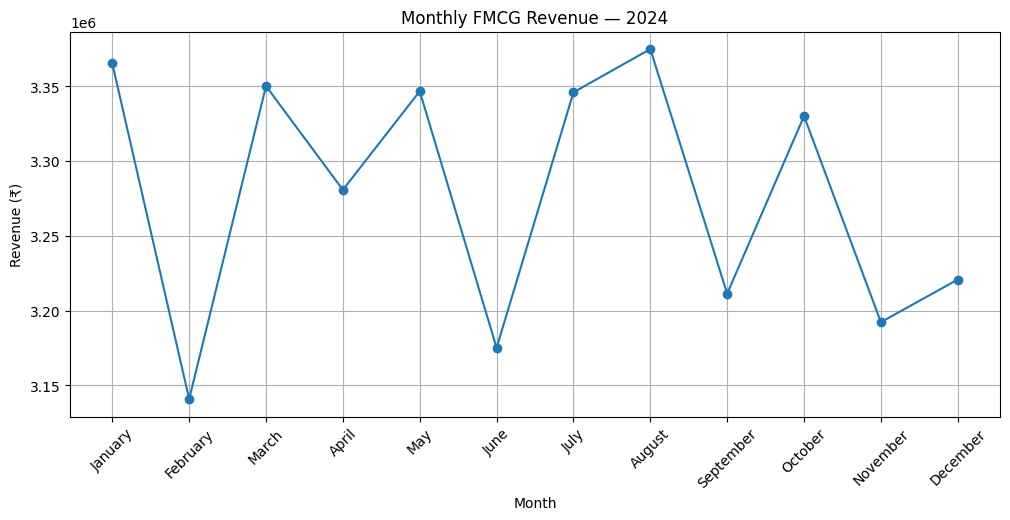

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Month_Name'],
    monthly_sales['Revenue'],
    marker='o'
)

plt.title('Monthly FMCG Revenue — 2024')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [53]:
best_month = monthly_sales.loc[
    monthly_sales['Revenue'].idxmax()
]

worst_month = monthly_sales.loc[
    monthly_sales['Revenue'].idxmin()
]

print("Best Month:")
print(best_month)

print("\nWorst Month:")
print(worst_month)

Best Month:
Month                      8
Revenue       3375015.057607
Cost          2696940.130483
Margin         678074.927123
Units                  25521
Margin_%           20.091019
Month_Name            August
Name: 7, dtype: object

Worst Month:
Month                      2
Revenue       3140896.094814
Cost          2506310.218859
Margin         634585.875954
Units                  23686
Margin_%           20.203975
Month_Name          February
Name: 1, dtype: object


In [54]:
category_analysis = (
    df_clean
    .groupby('Category')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_analysis['Margin_%'] = (
    category_analysis['Margin'] /
    category_analysis['Revenue'] * 100
)

category_analysis = category_analysis.sort_values(
    'Revenue',
    ascending=False
)

category_analysis

,Category,Revenue,Cost,Margin,Units,Transactions,Margin_%
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,12708,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,12412,20.144767
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,12514,20.072863
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,12585,19.899459
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,12630,19.920707
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,12472,20.054679
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,12409,20.097242
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,12270,20.022608


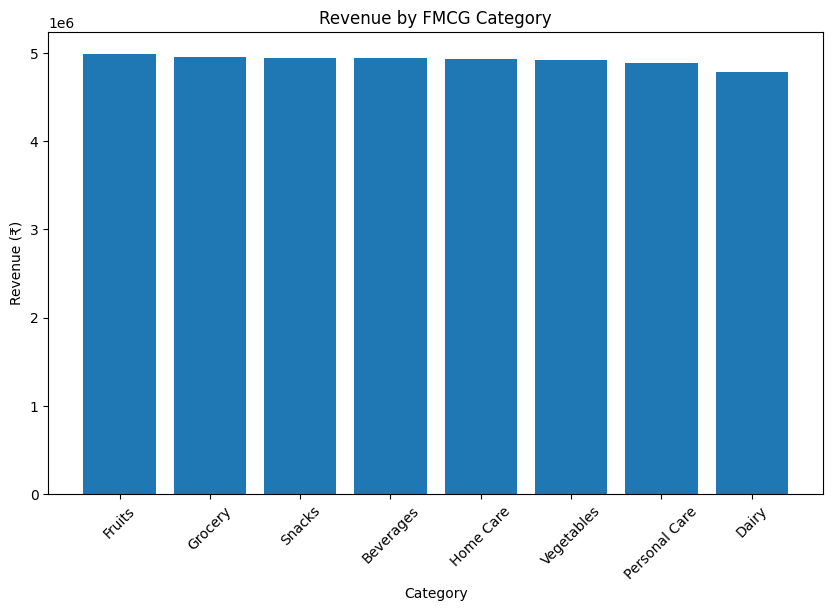

In [55]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis['Category'],
    category_analysis['Revenue']
)

plt.title('Revenue by FMCG Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)

plt.show()

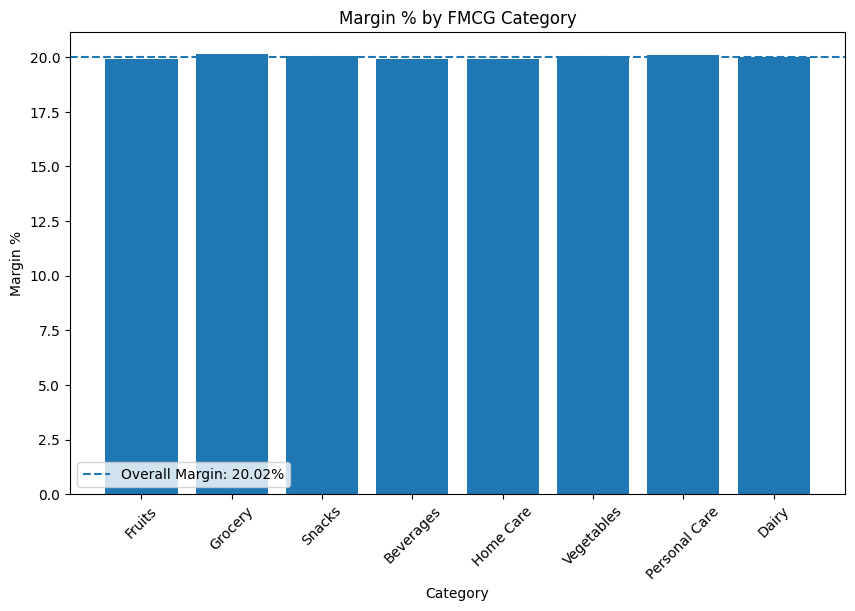

In [56]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis['Category'],
    category_analysis['Margin_%']
)

plt.axhline(
    y=overall_margin_pct,
    linestyle='--',
    label=f'Overall Margin: {overall_margin_pct:.2f}%'
)

plt.title('Margin % by FMCG Category')
plt.xlabel('Category')
plt.ylabel('Margin %')
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [57]:
brand_analysis = (
    df_clean
    .groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

brand_analysis['Margin_%'] = (
    brand_analysis['Margin'] /
    brand_analysis['Revenue'] * 100
)

brand_analysis = brand_analysis.sort_values(
    'Revenue',
    ascending=False
)

brand_analysis

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12649,20.030033
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12572,19.998571
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12521,20.183960
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12507,19.918014
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549


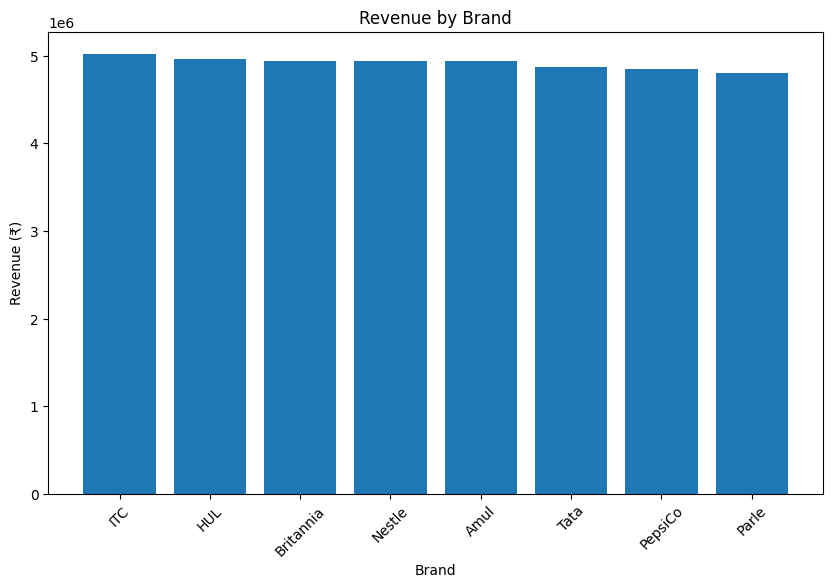

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    brand_analysis['Brand'],
    brand_analysis['Revenue']
)

plt.title('Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)

plt.show()

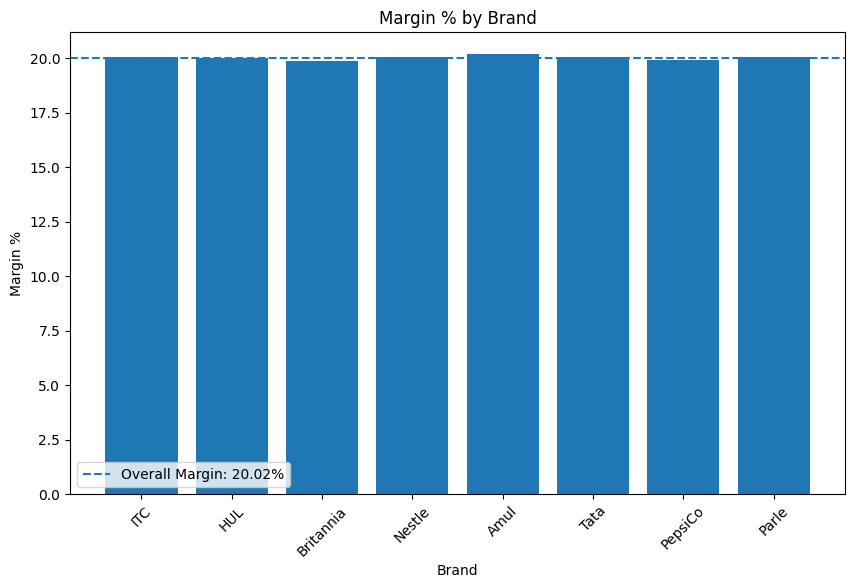

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    brand_analysis['Brand'],
    brand_analysis['Margin_%']
)

plt.axhline(
    y=overall_margin_pct,
    linestyle='--',
    label=f'Overall Margin: {overall_margin_pct:.2f}%'
)

plt.title('Margin % by Brand')
plt.xlabel('Brand')
plt.ylabel('Margin %')
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [60]:
brand_category = (
    df_clean
    .groupby(['Category', 'Brand'])
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

brand_category['Margin_%'] = (
    brand_category['Margin'] /
    brand_category['Revenue'] * 100
)

brand_category

,Category,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
0,Beverages,Amul,632424.072252,505735.930698,126688.141554,4879,1602,20.032150
1,Beverages,Britannia,621053.761248,499273.170988,121780.590260,4669,1553,19.608703
2,Beverages,HUL,617387.280631,494952.826179,122434.454452,4826,1597,19.831062
3,Beverages,ITC,635310.473768,510108.541626,125201.932142,4779,1581,19.707204
4,Beverages,Nestle,615667.063505,491997.626436,123669.437068,4676,1586,20.087064
5,Beverages,Parle,600094.423961,481049.496576,119044.927385,4661,1534,19.837699
6,Beverages,PepsiCo,602990.848225,482443.988577,120546.859648,4637,1561,19.991491
7,Beverages,Tata,616102.247043,492230.316333,123871.930710,4736,1571,20.105742
8,Dairy,Amul,604374.379712,484457.206241,119917.173471,4669,1550,19.841538
9,Dairy,Britannia,618501.162691,495541.627850,122959.534841,4747,1575,19.880243


In [61]:
top_brand_by_category = (
    brand_category
    .sort_values(['Category', 'Revenue'], ascending=[True, False])
    .groupby('Category')
    .head(1)
)

top_brand_by_category

,Category,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
3,Beverages,ITC,635310.473768,510108.541626,125201.932142,4779,1581,19.707204
9,Dairy,Britannia,618501.162691,495541.627850,122959.534841,4747,1575,19.880243
17,Fruits,Britannia,647694.129452,517317.244972,130376.884480,5003,1640,20.129391
24,Grocery,Amul,636096.635273,505794.264447,130302.370826,4853,1611,20.484682
32,Home Care,Amul,637393.689531,507397.737004,129995.952527,4886,1633,20.394923
42,Personal Care,HUL,624157.732683,498598.345068,125559.387615,4780,1622,20.116612
51,Snacks,ITC,659238.570368,526480.618209,132757.952159,5071,1643,20.138074
59,Vegetables,ITC,642859.437229,514428.157909,128431.279320,4822,1599,19.978128


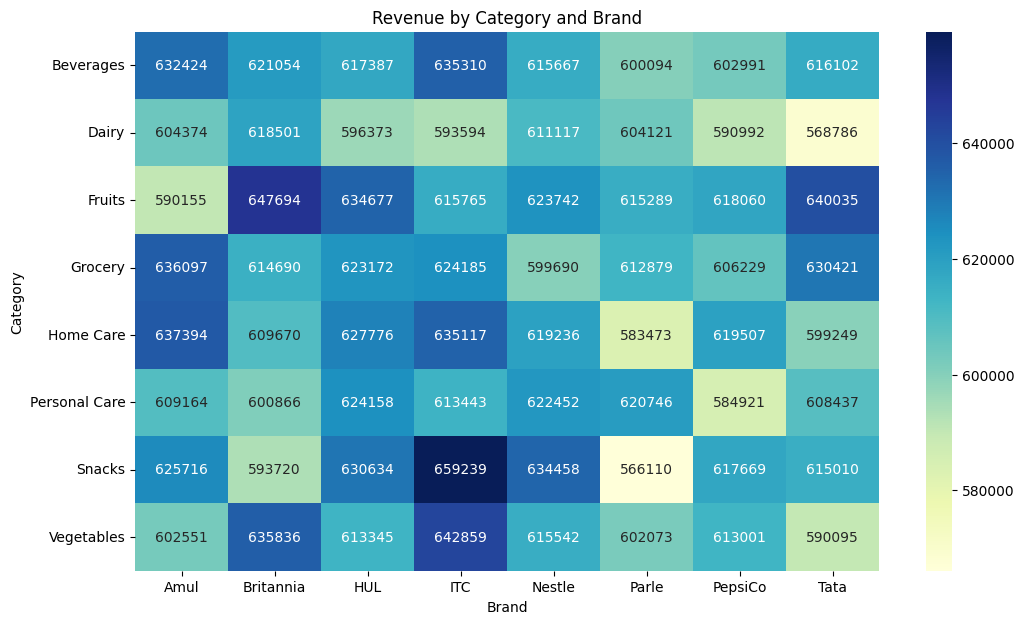

In [62]:
import seaborn as sns

pivot_revenue = brand_category.pivot(
    index='Category',
    columns='Brand',
    values='Revenue'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot_revenue,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Revenue by Category and Brand')
plt.xlabel('Brand')
plt.ylabel('Category')

plt.show()

In [63]:
top_margin_by_category = (
    brand_category
    .sort_values(
        ['Category', 'Margin_%'],
        ascending=[True, False]
    )
    .groupby('Category')
    .head(1)
)

top_margin_by_category[
    [
        'Category',
        'Brand',
        'Revenue',
        'Margin',
        'Margin_%',
        'Units',
        'Transactions'
    ]
]

,Category,Brand,Revenue,Margin,Margin_%,Units,Transactions
7,Beverages,Tata,616102.247043,123871.930710,20.105742,4736,1571
12,Dairy,Nestle,611117.456390,124474.186251,20.368292,4635,1547
17,Fruits,Britannia,647694.129452,130376.884480,20.129391,5003,1640
24,Grocery,Amul,636096.635273,130302.370826,20.484682,4853,1611
32,Home Care,Amul,637393.689531,129995.952527,20.394923,4886,1633
43,Personal Care,ITC,613443.442702,124709.694439,20.329453,4524,1533
48,Snacks,Amul,625715.620412,127965.129094,20.451004,4681,1564
58,Vegetables,HUL,613345.460739,125694.251580,20.493223,4568,1511


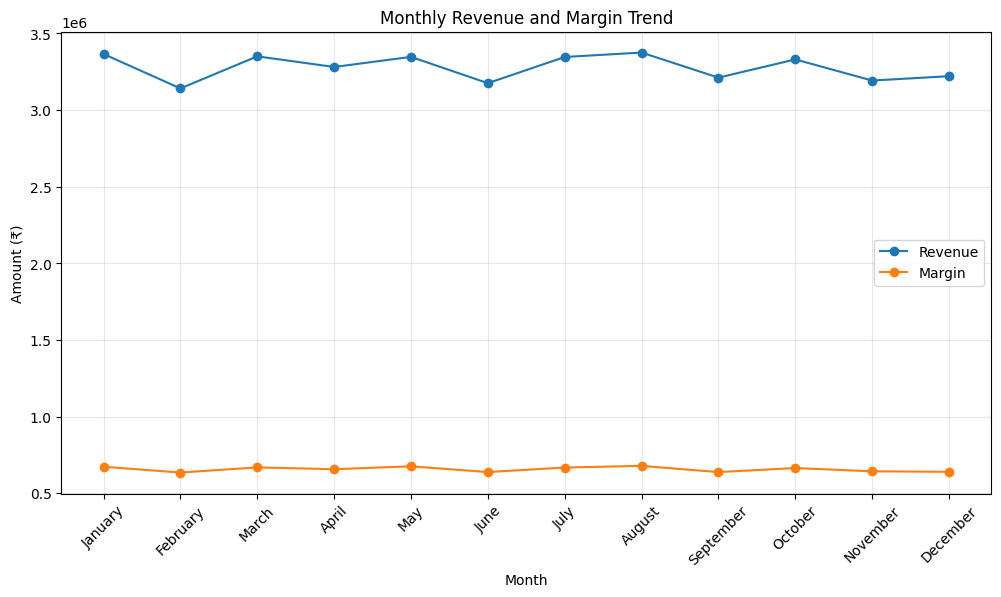

In [64]:
import matplotlib.pyplot as plt

monthly_sales = (
    df_clean.groupby(['Month', 'Month_Name'])
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum')
    )
    .reset_index()
    .sort_values('Month')
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['Month_Name'],
    monthly_sales['Revenue'],
    marker='o',
    label='Revenue'
)

plt.plot(
    monthly_sales['Month_Name'],
    monthly_sales['Margin'],
    marker='o',
    label='Margin'
)

plt.title('Monthly Revenue and Margin Trend')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [65]:
category_analysis = (
    df_clean.groupby('Category')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_analysis['Margin_%'] = (
    category_analysis['Margin'] /
    category_analysis['Revenue'] * 100
)

category_analysis = category_analysis.sort_values(
    'Revenue',
    ascending=False
)

category_analysis

,Category,Revenue,Cost,Margin,Units,Transactions,Margin_%
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,12708,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,12412,20.144767
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,12514,20.072863
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,12585,19.899459
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,12630,19.920707
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,12472,20.054679
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,12409,20.097242
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,12270,20.022608


In [66]:
category_analysis = (
    df_clean.groupby('Category')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_analysis['Margin_%'] = (
    category_analysis['Margin'] /
    category_analysis['Revenue'] * 100
)

category_analysis = category_analysis.sort_values(
    'Revenue',
    ascending=False
)

category_analysis

,Category,Revenue,Cost,Margin,Units,Transactions,Margin_%
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,12708,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,12412,20.144767
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,12514,20.072863
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,12585,19.899459
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,12630,19.920707
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,12472,20.054679
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,12409,20.097242
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,12270,20.022608


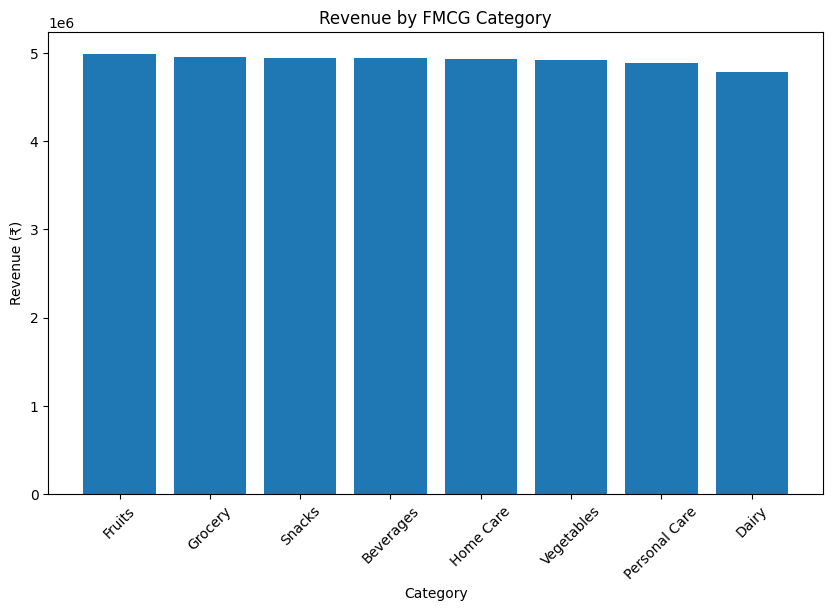

In [67]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis['Category'],
    category_analysis['Revenue']
)

plt.title('Revenue by FMCG Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)

plt.show()

In [68]:
brand_analysis = (
    df_clean.groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

brand_analysis['Margin_%'] = (
    brand_analysis['Margin'] /
    brand_analysis['Revenue'] * 100
)

brand_analysis = brand_analysis.sort_values(
    'Revenue',
    ascending=False
)

brand_analysis

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12649,20.030033
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12572,19.998571
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12521,20.183960
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12507,19.918014
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549


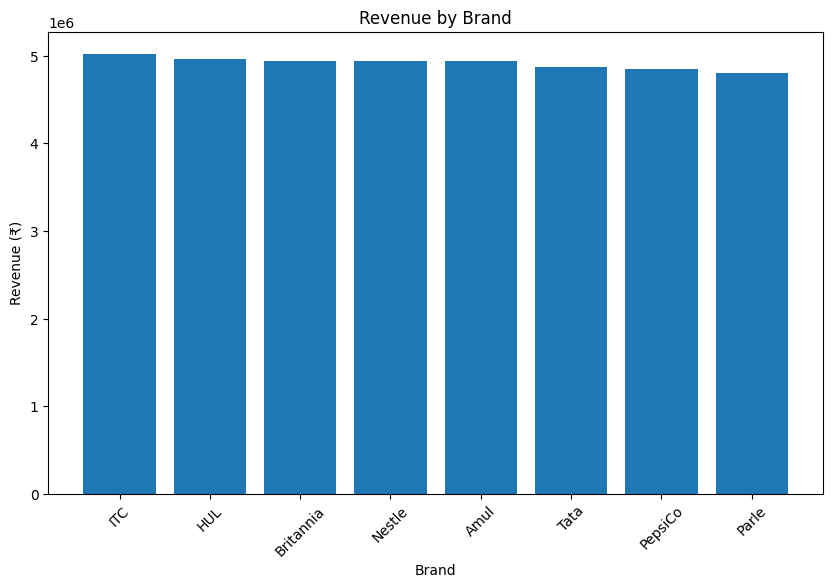

In [69]:
plt.figure(figsize=(10, 6))

plt.bar(
    brand_analysis['Brand'],
    brand_analysis['Revenue']
)

plt.title('Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)

plt.show()

In [70]:
city_analysis = (
    df_clean.groupby('City')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

city_analysis['Margin_%'] = (
    city_analysis['Margin'] /
    city_analysis['Revenue'] * 100
)

city_analysis = city_analysis.sort_values(
    'Revenue',
    ascending=False
)

city_analysis

,City,Revenue,Cost,Margin,Units,Transactions,Margin_%
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049,12681,19.974711
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946,12649,19.999590
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568,12440,19.987730
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533,12467,20.057972
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018,12403,20.147878
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273,12492,20.094427
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209,12436,19.915981
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233,12432,19.957266


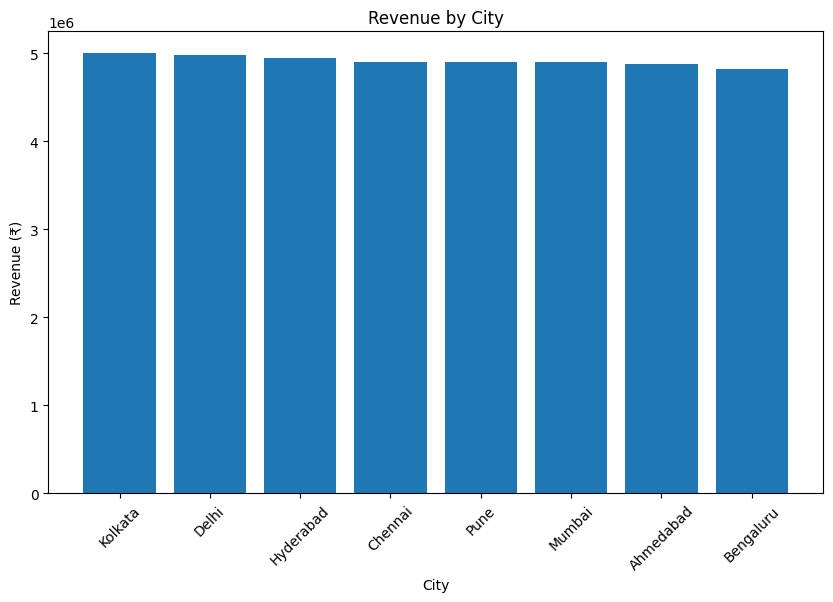

In [71]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_analysis['City'],
    city_analysis['Revenue']
)

plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)

plt.show()

In [72]:
channel_analysis = (
    df_clean.groupby('Channel')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

channel_analysis['Margin_%'] = (
    channel_analysis['Margin'] /
    channel_analysis['Revenue'] * 100
)

channel_analysis['Avg_Transaction_Value'] = (
    channel_analysis['Revenue'] /
    channel_analysis['Transactions']
)

channel_analysis

,Channel,Revenue,Cost,Margin,Units,Transactions,Margin_%,Avg_Transaction_Value
0,Offline,1.305448e+07,1.044516e+07,2.609320e+06,99698,33362,19.987919,391.297991
1,Omnichannel,1.316299e+07,1.052513e+07,2.637861e+06,100280,33383,20.039982,394.302262
2,Online,1.311766e+07,1.049115e+07,2.626505e+06,99851,33255,20.022664,394.456744


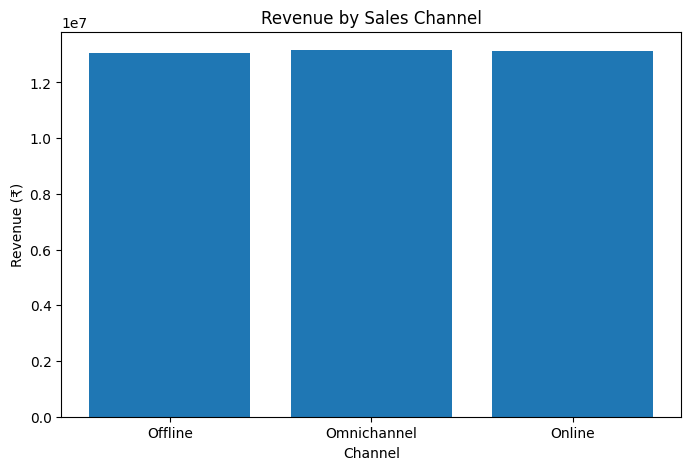

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_analysis['Channel'],
    channel_analysis['Revenue']
)

plt.title('Revenue by Sales Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue (₹)')

plt.show()

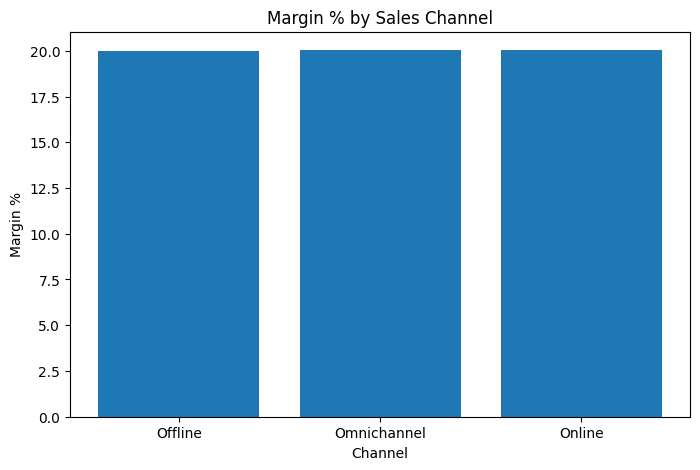

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_analysis['Channel'],
    channel_analysis['Margin_%']
)

plt.title('Margin % by Sales Channel')
plt.xlabel('Channel')
plt.ylabel('Margin %')

plt.show()

In [75]:
store_analysis = (
    df_clean.groupby('Store_Format')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

store_analysis['Margin_%'] = (
    store_analysis['Margin'] /
    store_analysis['Revenue'] * 100
)

store_analysis['Avg_Transaction_Value'] = (
    store_analysis['Revenue'] /
    store_analysis['Transactions']
)

store_analysis

,Store_Format,Revenue,Cost,Margin,Units,Transactions,Margin_%,Avg_Transaction_Value
0,Express,1.300991e+07,1.040686e+07,2.603055e+06,99897,33314,20.008240,390.523924
1,Hyper,1.322563e+07,1.058109e+07,2.644536e+06,100671,33443,19.995543,395.467698
2,Super,1.309959e+07,1.047350e+07,2.626095e+06,99261,33243,20.047146,394.055733


In [76]:
total_revenue = df_clean['Revenue'].sum()
total_cost = df_clean['Cost'].sum()
total_margin = df_clean['Margin'].sum()
total_units = df_clean['Units'].sum()
total_transactions = len(df_clean)

overall_margin_pct = (
    total_margin / total_revenue * 100
)

avg_transaction_value = (
    total_revenue / total_transactions
)

avg_units_per_transaction = (
    total_units / total_transactions
)

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Cost',
        'Total Margin',
        'Margin %',
        'Total Units',
        'Transactions',
        'Average Transaction Value',
        'Average Units per Transaction'
    ],
    'Value': [
        total_revenue,
        total_cost,
        total_margin,
        overall_margin_pct,
        total_units,
        total_transactions,
        avg_transaction_value,
        avg_units_per_transaction
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,3.933513e+07
1,Total Cost,3.146145e+07
2,Total Margin,7.873686e+06
3,Margin %,2.001693e+01
4,Total Units,2.998290e+05
5,Transactions,1.000000e+05
6,Average Transaction Value,3.933513e+02
7,Average Units per Transaction,2.998290e+00


In [77]:
# ==========================================
# PROFITABILITY ANALYSIS
# ==========================================

# Category profitability
category_profit = (
    df_clean.groupby('Category')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_profit['Margin_%'] = (
    category_profit['Margin'] / category_profit['Revenue'] * 100
)

category_profit = category_profit.sort_values(
    'Margin', ascending=False
)

category_profit

,Category,Revenue,Cost,Margin,Units,Transactions,Margin_%
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,12412,20.144767
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,12708,19.924854
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,12514,20.072863
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,12472,20.054679
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,12585,19.899459
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,12630,19.920707
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,12409,20.097242
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,12270,20.022608


In [78]:
# Brand profitability
brand_profit = (
    df_clean.groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

brand_profit['Margin_%'] = (
    brand_profit['Margin'] / brand_profit['Revenue'] * 100
)

brand_profit = brand_profit.sort_values(
    'Margin', ascending=False
)

brand_profit

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12649,20.030033
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12521,20.183960
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12572,19.998571
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12507,19.918014
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549


In [79]:
# City profitability
city_profit = (
    df_clean.groupby('City')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

city_profit['Margin_%'] = (
    city_profit['Margin'] / city_profit['Revenue'] * 100
)

city_profit = city_profit.sort_values(
    'Margin', ascending=False
)

city_profit

,City,Revenue,Cost,Margin,Units,Transactions,Margin_%
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049,12681,19.974711
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946,12649,19.999590
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568,12440,19.987730
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018,12403,20.147878
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273,12492,20.094427
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533,12467,20.057972
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209,12436,19.915981
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233,12432,19.957266


In [80]:
category_profit[['Category', 'Revenue', 'Margin', 'Margin_%']] \
    .sort_values('Revenue', ascending=False)

,Category,Revenue,Margin,Margin_%
2,Fruits,4.985418e+06,993337.256857,19.924854
3,Grocery,4.947363e+06,996634.794798,20.144767
6,Snacks,4.942555e+06,992112.232178,20.072863
0,Beverages,4.941030e+06,983238.273218,19.899459
4,Home Care,4.931420e+06,982373.840734,19.920707
7,Vegetables,4.915302e+06,985748.003486,20.054679
5,Personal Care,4.884187e+06,981586.979222,20.097242
1,Dairy,4.787859e+06,958654.274803,20.022608


In [81]:
category_profit[['Category', 'Revenue', 'Margin', 'Margin_%']] \
    .sort_values('Margin_%', ascending=False)

,Category,Revenue,Margin,Margin_%
3,Grocery,4.947363e+06,996634.794798,20.144767
5,Personal Care,4.884187e+06,981586.979222,20.097242
6,Snacks,4.942555e+06,992112.232178,20.072863
7,Vegetables,4.915302e+06,985748.003486,20.054679
1,Dairy,4.787859e+06,958654.274803,20.022608
2,Fruits,4.985418e+06,993337.256857,19.924854
4,Home Care,4.931420e+06,982373.840734,19.920707
0,Beverages,4.941030e+06,983238.273218,19.899459


In [82]:
inventory_analysis = (
    df_clean.groupby(['Category', 'Reorder_Flag'])
    .agg(
        Units=('Units', 'sum'),
        Revenue=('Revenue', 'sum'),
        Stock=('Stock_On_Hand', 'mean'),
        Reorder_Level=('Reorder_Level', 'mean'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

inventory_analysis

,Category,Reorder_Flag,Units,Revenue,Stock,Reorder_Level,Transactions
0,Beverages,Reorder Required,683,8.623754e+04,58.753363,68.959641,223
1,Beverages,Stock Sufficient,37180,4.854793e+06,278.287818,49.034865,12362
2,Dairy,Reorder Required,700,9.140252e+04,59.902128,69.119149,235
3,Dairy,Stock Sufficient,36070,4.696457e+06,278.376319,49.073619,12035
4,Fruits,Reorder Required,579,6.982913e+04,59.524272,70.398058,206
5,Fruits,Stock Sufficient,37616,4.915589e+06,277.869221,49.082947,12502
6,Grocery,Reorder Required,657,9.046721e+04,59.100000,69.090909,220
7,Grocery,Stock Sufficient,36743,4.856896e+06,277.328740,49.380249,12192
8,Home Care,Reorder Required,610,7.749923e+04,58.832512,68.600985,203
9,Home Care,Stock Sufficient,37180,4.853921e+06,277.837370,49.046753,12427


In [83]:
reorder_summary = (
    df_clean[df_clean['Reorder_Flag'] == 'Reorder Required']
    .groupby('Category')
    .agg(
        Reorder_Transactions=('Invoice_ID', 'count'),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum')
    )
    .reset_index()
    .sort_values('Reorder_Transactions', ascending=False)
)

reorder_summary

,Category,Reorder_Transactions,Revenue,Units
1,Dairy,235,91402.524108,700
6,Snacks,224,90289.699995,653
0,Beverages,223,86237.537251,683
3,Grocery,220,90467.213044,657
5,Personal Care,219,82511.166893,636
2,Fruits,206,69829.126218,579
4,Home Care,203,77499.228660,610
7,Vegetables,199,80894.945714,611


In [84]:
inventory_risk = (
    df_clean[df_clean['Reorder_Flag'] == 'Reorder Required']
    .groupby(['City', 'Category'])
    .agg(
        Reorder_Count=('Invoice_ID', 'count'),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum'),
        Avg_Stock=('Stock_On_Hand', 'mean'),
        Avg_Reorder_Level=('Reorder_Level', 'mean'),
        Avg_Lead_Time=('Lead_Time_Days', 'mean')
    )
    .reset_index()
)

inventory_risk = inventory_risk.sort_values(
    'Reorder_Count',
    ascending=False
)

inventory_risk.head(15)

,City,Category,Reorder_Count,Revenue,Units,Avg_Stock,Avg_Reorder_Level,Avg_Lead_Time
49,Mumbai,Dairy,41,17405.055189,134,59.780488,69.414634,9.756098
22,Chennai,Snacks,40,14370.924072,114,59.400000,68.725000,8.775000
62,Pune,Snacks,37,14323.423873,115,60.567568,69.675676,8.189189
53,Mumbai,Personal Care,36,15793.168308,107,58.944444,68.611111,8.166667
48,Mumbai,Beverages,34,12526.744356,97,58.411765,69.117647,7.794118
39,Hyderabad,Vegetables,33,12782.285161,98,59.757576,69.000000,9.242424
51,Mumbai,Grocery,33,14910.331445,106,60.212121,68.030303,9.242424
0,Ahmedabad,Beverages,32,10799.639738,91,59.968750,68.562500,7.468750
33,Hyderabad,Dairy,32,12131.439501,97,58.812500,69.500000,8.531250
43,Kolkata,Grocery,32,10427.475142,79,58.750000,68.375000,8.312500


In [85]:
customer_analysis = (
    df_clean.groupby('Age_Group')
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

customer_analysis['Margin_%'] = (
    customer_analysis['Margin'] /
    customer_analysis['Revenue'] * 100
)

customer_analysis

/tmp/ipykernel_2705/3141977088.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Age_Group')


,Age_Group,Revenue,Margin,Units,Transactions,Margin_%
0,Under 18,4.911896e+05,1.008755e+05,3822,1271,20.536985
1,18-25,3.409519e+06,6.814889e+05,26348,8833,19.987831
2,26-35,4.970499e+06,9.915639e+05,37941,12676,19.948980
3,36-45,5.056440e+06,1.014033e+06,38380,12777,20.054289
4,46-55,5.032784e+06,1.001026e+06,38369,12814,19.890108
5,56-65,4.538993e+06,9.151138e+05,34379,11548,20.161163
6,65+,0.000000e+00,0.000000e+00,0,0,NaN
7,Unknown,1.583571e+07,3.169584e+06,120590,40081,20.015422


In [86]:
loyalty_analysis = (
    df_clean.groupby('Loyalty_Flag')
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

loyalty_analysis['Margin_%'] = (
    loyalty_analysis['Margin'] /
    loyalty_analysis['Revenue'] * 100
)

loyalty_analysis

,Loyalty_Flag,Revenue,Margin,Units,Transactions,Margin_%
0,0,2.758148e+07,5.520246e+06,210364,70280,20.014320
1,1,1.175365e+07,2.353439e+06,89465,29720,20.023047


In [87]:
day_analysis = (
    df_clean.groupby('Day_Name')
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

day_analysis['Margin_%'] = (
    day_analysis['Margin'] /
    day_analysis['Revenue'] * 100
)

day_analysis

,Day_Name,Revenue,Margin,Units,Transactions,Margin_%
0,Friday,5.603408e+06,1.123070e+06,42544,14285,20.042619
1,Monday,5.707122e+06,1.139993e+06,43469,14554,19.974928
2,Saturday,5.523320e+06,1.107680e+06,42425,14152,20.054607
3,Sunday,5.602529e+06,1.116447e+06,42561,14093,19.927553
4,Thursday,5.650096e+06,1.124813e+06,43114,14367,19.907850
5,Tuesday,5.632918e+06,1.128918e+06,43016,14336,20.041448
6,Wednesday,5.615741e+06,1.132764e+06,42700,14213,20.171233


In [88]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_analysis['Day_Name'] = pd.Categorical(
    day_analysis['Day_Name'],
    categories=day_order,
    ordered=True
)

day_analysis = day_analysis.sort_values('Day_Name')

day_analysis

,Day_Name,Revenue,Margin,Units,Transactions,Margin_%
1,Monday,5.707122e+06,1.139993e+06,43469,14554,19.974928
5,Tuesday,5.632918e+06,1.128918e+06,43016,14336,20.041448
6,Wednesday,5.615741e+06,1.132764e+06,42700,14213,20.171233
4,Thursday,5.650096e+06,1.124813e+06,43114,14367,19.907850
0,Friday,5.603408e+06,1.123070e+06,42544,14285,20.042619
2,Saturday,5.523320e+06,1.107680e+06,42425,14152,20.054607
3,Sunday,5.602529e+06,1.116447e+06,42561,14093,19.927553


In [89]:
# Category + Brand performance
category_brand_perf = (
    df_clean.groupby(['Category', 'Brand'])
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_brand_perf['Margin_%'] = (
    category_brand_perf['Margin'] /
    category_brand_perf['Revenue'] * 100
)

# Sort by revenue
category_brand_revenue = category_brand_perf.sort_values(
    'Revenue', ascending=False
)

category_brand_revenue.head(10)

,Category,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
51,Snacks,ITC,659238.570368,526480.618209,132757.952159,5071,1643,20.138074
17,Fruits,Britannia,647694.129452,517317.244972,130376.884480,5003,1640,20.129391
59,Vegetables,ITC,642859.437229,514428.157909,128431.279320,4822,1599,19.978128
23,Fruits,Tata,640035.324837,511778.748380,128256.576457,4940,1617,20.038984
32,Home Care,Amul,637393.689531,507397.737004,129995.952527,4886,1633,20.394923
24,Grocery,Amul,636096.635273,505794.264447,130302.370826,4853,1611,20.484682
57,Vegetables,Britannia,635835.963660,508315.618368,127520.345292,4783,1599,20.055541
3,Beverages,ITC,635310.473768,510108.541626,125201.932142,4779,1581,19.707204
35,Home Care,ITC,635116.740352,507677.245838,127439.494514,4799,1587,20.065523
18,Fruits,HUL,634677.338200,509678.334947,124999.003253,4708,1580,19.694890


In [90]:
# Top Category + Brand combinations by Margin
category_brand_margin = category_brand_perf.sort_values(
    'Margin', ascending=False
)

category_brand_margin.head(10)

,Category,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
51,Snacks,ITC,659238.570368,526480.618209,132757.952159,5071,1643,20.138074
17,Fruits,Britannia,647694.129452,517317.244972,130376.884480,5003,1640,20.129391
24,Grocery,Amul,636096.635273,505794.264447,130302.370826,4853,1611,20.484682
32,Home Care,Amul,637393.689531,507397.737004,129995.952527,4886,1633,20.394923
59,Vegetables,ITC,642859.437229,514428.157909,128431.279320,4822,1599,19.978128
23,Fruits,Tata,640035.324837,511778.748380,128256.576457,4940,1617,20.038984
48,Snacks,Amul,625715.620412,497750.491318,127965.129094,4681,1564,20.451004
31,Grocery,Tata,630421.198375,502893.476128,127527.722247,4627,1542,20.228971
57,Vegetables,Britannia,635835.963660,508315.618368,127520.345292,4783,1599,20.055541
35,Home Care,ITC,635116.740352,507677.245838,127439.494514,4799,1587,20.065523


In [91]:
# Highest margin % combinations
category_brand_margin_pct = category_brand_perf.sort_values(
    'Margin_%', ascending=False
)

category_brand_margin_pct.head(10)

,Category,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%
58,Vegetables,HUL,613345.460739,487651.209159,125694.251580,4568,1511,20.493223
24,Grocery,Amul,636096.635273,505794.264447,130302.370826,4853,1611,20.484682
48,Snacks,Amul,625715.620412,497750.491318,127965.129094,4681,1564,20.451004
32,Home Care,Amul,637393.689531,507397.737004,129995.952527,4886,1633,20.394923
12,Dairy,Nestle,611117.456390,486643.270138,124474.186251,4635,1547,20.368292
43,Personal Care,ITC,613443.442702,488733.748263,124709.694439,4524,1533,20.329453
46,Personal Care,PepsiCo,584921.490921,466069.439153,118852.051768,4435,1513,20.319317
28,Grocery,Nestle,599690.035125,478062.143838,121627.891286,4546,1509,20.281793
49,Snacks,Britannia,593719.627821,473588.792029,120130.835792,4428,1475,20.233597
31,Grocery,Tata,630421.198375,502893.476128,127527.722247,4627,1542,20.228971


In [92]:
# Reorder analysis by city
reorder_city = (
    df_clean[df_clean['Reorder_Flag'] == 'Reorder Required']
    .groupby('City')
    .agg(
        Reorder_Count=('Invoice_ID', 'count'),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum')
    )
    .reset_index()
    .sort_values('Reorder_Count', ascending=False)
)

reorder_city

,City,Reorder_Count,Revenue,Units
5,Kolkata,234,97182.210749,687
6,Mumbai,232,90859.177381,709
2,Chennai,231,89450.662046,698
4,Hyderabad,214,76869.098715,618
7,Pune,213,75713.929652,630
3,Delhi,208,82032.262846,617
1,Bengaluru,205,84754.558576,626
0,Ahmedabad,192,72269.541916,544


In [93]:
# Reorder analysis by category
reorder_category = (
    df_clean[df_clean['Reorder_Flag'] == 'Reorder Required']
    .groupby('Category')
    .agg(
        Reorder_Count=('Invoice_ID', 'count'),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum')
    )
    .reset_index()
    .sort_values('Reorder_Count', ascending=False)
)

reorder_category

,Category,Reorder_Count,Revenue,Units
1,Dairy,235,91402.524108,700
6,Snacks,224,90289.699995,653
0,Beverages,223,86237.537251,683
3,Grocery,220,90467.213044,657
5,Personal Care,219,82511.166893,636
2,Fruits,206,69829.126218,579
4,Home Care,203,77499.228660,610
7,Vegetables,199,80894.945714,611


In [94]:
# City + Category inventory risk
reorder_city_category = (
    df_clean[df_clean['Reorder_Flag'] == 'Reorder Required']
    .groupby(['City', 'Category'])
    .agg(
        Reorder_Count=('Invoice_ID', 'count'),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum'),
        Avg_Stock=('Stock_On_Hand', 'mean'),
        Avg_Reorder_Level=('Reorder_Level', 'mean'),
        Avg_Lead_Time=('Lead_Time_Days', 'mean')
    )
    .reset_index()
    .sort_values('Reorder_Count', ascending=False)
)

reorder_city_category.head(15)

,City,Category,Reorder_Count,Revenue,Units,Avg_Stock,Avg_Reorder_Level,Avg_Lead_Time
49,Mumbai,Dairy,41,17405.055189,134,59.780488,69.414634,9.756098
22,Chennai,Snacks,40,14370.924072,114,59.400000,68.725000,8.775000
62,Pune,Snacks,37,14323.423873,115,60.567568,69.675676,8.189189
53,Mumbai,Personal Care,36,15793.168308,107,58.944444,68.611111,8.166667
48,Mumbai,Beverages,34,12526.744356,97,58.411765,69.117647,7.794118
39,Hyderabad,Vegetables,33,12782.285161,98,59.757576,69.000000,9.242424
51,Mumbai,Grocery,33,14910.331445,106,60.212121,68.030303,9.242424
0,Ahmedabad,Beverages,32,10799.639738,91,59.968750,68.562500,7.468750
33,Hyderabad,Dairy,32,12131.439501,97,58.812500,69.500000,8.531250
43,Kolkata,Grocery,32,10427.475142,79,58.750000,68.375000,8.312500


In [95]:
category_analysis = (
    df_clean.groupby('Category')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

category_analysis['Margin_%'] = (
    category_analysis['Margin'] /
    category_analysis['Revenue'] * 100
)

category_analysis['Revenue_Share_%'] = (
    category_analysis['Revenue'] /
    category_analysis['Revenue'].sum() * 100
)

category_analysis.sort_values('Revenue', ascending=False)

,Category,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,12708,19.924854,12.674211
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,12412,20.144767,12.577466
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,12514,20.072863,12.565241
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,12585,19.899459,12.561366
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,12630,19.920707,12.536935
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,12472,20.054679,12.495958
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,12409,20.097242,12.416857
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,12270,20.022608,12.171966


In [96]:
customer_segment = (
    df_clean.groupby(['Age_Group', 'Loyalty_Flag'])
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

customer_segment['Margin_%'] = (
    customer_segment['Margin'] /
    customer_segment['Revenue'] * 100
)

customer_segment['Avg_Transaction_Value'] = (
    customer_segment['Revenue'] /
    customer_segment['Transactions']
)

customer_segment.sort_values('Revenue', ascending=False)

/tmp/ipykernel_2705/3977089180.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['Age_Group', 'Loyalty_Flag'])


,Age_Group,Loyalty_Flag,Revenue,Margin,Units,Transactions,Margin_%,Avg_Transaction_Value
14,Unknown,0,1.114341e+07,2.231500e+06,84665,28193,20.025283,395.254581
15,Unknown,1,4.692298e+06,9.380846e+05,35925,11888,19.992005,394.708823
8,46-55,0,3.594041e+06,7.137241e+05,27399,9128,19.858539,393.738082
6,36-45,0,3.505172e+06,7.007716e+05,26763,8925,19.992504,392.736325
4,26-35,0,3.456703e+06,6.887965e+05,26382,8849,19.926402,390.632031
10,56-65,0,3.161894e+06,6.392963e+05,23984,8098,20.218776,390.453734
2,18-25,0,2.362220e+06,4.726913e+05,18370,6162,20.010466,383.352843
7,36-45,1,1.551268e+06,3.132615e+05,11617,3852,20.193895,402.717673
5,26-35,1,1.513796e+06,3.027674e+05,11559,3827,20.000537,395.556871
9,46-55,1,1.438742e+06,2.873020e+05,10970,3686,19.968970,390.326208


In [97]:
# Reorder rate by City + Category

inventory_risk = (
    df_clean.groupby(['City', 'Category'])
    .agg(
        Total_Transactions=('Invoice_ID', 'count'),
        Reorder_Transactions=(
            'Reorder_Flag',
            lambda x: (x == 'Reorder Required').sum()
        ),
        Revenue=('Revenue', 'sum'),
        Units=('Units', 'sum'),
        Avg_Stock=('Stock_On_Hand', 'mean'),
        Avg_Reorder_Level=('Reorder_Level', 'mean'),
        Avg_Lead_Time=('Lead_Time_Days', 'mean')
    )
    .reset_index()
)

inventory_risk['Reorder_Rate_%'] = (
    inventory_risk['Reorder_Transactions'] /
    inventory_risk['Total_Transactions'] * 100
)

inventory_risk = inventory_risk.sort_values(
    'Reorder_Rate_%',
    ascending=False
)

inventory_risk.head(15)

,City,Category,Total_Transactions,Reorder_Transactions,Revenue,Units,Avg_Stock,Avg_Reorder_Level,Avg_Lead_Time,Reorder_Rate_%
49,Mumbai,Dairy,1582,41,598719.448575,4599,273.739570,49.367257,8.652339,2.591656
22,Chennai,Snacks,1550,40,592491.530187,4621,273.405161,49.476129,8.392258,2.580645
62,Pune,Snacks,1537,37,629932.803595,4674,270.489265,50.640208,8.566688,2.407287
53,Mumbai,Personal Care,1543,36,611934.008661,4615,274.927414,50.239793,8.542450,2.333117
51,Mumbai,Grocery,1488,33,596696.899952,4448,277.097446,49.467742,8.514113,2.217742
48,Mumbai,Beverages,1544,34,603012.418453,4685,276.579016,49.244819,8.479922,2.202073
33,Hyderabad,Dairy,1475,32,585751.752147,4429,271.595254,49.613559,8.521356,2.169492
39,Hyderabad,Vegetables,1539,33,625874.687781,4726,273.055880,50.041585,8.545159,2.144250
14,Bengaluru,Snacks,1529,32,574516.676933,4466,270.659908,49.612819,8.411380,2.092871
43,Kolkata,Grocery,1540,32,606492.347091,4635,268.720130,49.695455,8.492857,2.077922


In [98]:
high_volume_risk = inventory_risk[
    inventory_risk['Total_Transactions'] >= 1000
].sort_values(
    'Reorder_Rate_%',
    ascending=False
)

high_volume_risk.head(15)

,City,Category,Total_Transactions,Reorder_Transactions,Revenue,Units,Avg_Stock,Avg_Reorder_Level,Avg_Lead_Time,Reorder_Rate_%
49,Mumbai,Dairy,1582,41,598719.448575,4599,273.739570,49.367257,8.652339,2.591656
22,Chennai,Snacks,1550,40,592491.530187,4621,273.405161,49.476129,8.392258,2.580645
62,Pune,Snacks,1537,37,629932.803595,4674,270.489265,50.640208,8.566688,2.407287
53,Mumbai,Personal Care,1543,36,611934.008661,4615,274.927414,50.239793,8.542450,2.333117
51,Mumbai,Grocery,1488,33,596696.899952,4448,277.097446,49.467742,8.514113,2.217742
48,Mumbai,Beverages,1544,34,603012.418453,4685,276.579016,49.244819,8.479922,2.202073
33,Hyderabad,Dairy,1475,32,585751.752147,4429,271.595254,49.613559,8.521356,2.169492
39,Hyderabad,Vegetables,1539,33,625874.687781,4726,273.055880,50.041585,8.545159,2.144250
14,Bengaluru,Snacks,1529,32,574516.676933,4466,270.659908,49.612819,8.411380,2.092871
43,Kolkata,Grocery,1540,32,606492.347091,4635,268.720130,49.695455,8.492857,2.077922


In [99]:
category_matrix = category_analysis.copy()

revenue_median = category_matrix['Revenue'].median()
margin_median = category_matrix['Margin'].median()

category_matrix['Revenue_Performance'] = np.where(
    category_matrix['Revenue'] >= revenue_median,
    'High Revenue',
    'Low Revenue'
)

category_matrix['Margin_Performance'] = np.where(
    category_matrix['Margin'] >= margin_median,
    'High Margin',
    'Low Margin'
)

category_matrix['Business_Type'] = (
    category_matrix['Revenue_Performance']
    + ' + '
    + category_matrix['Margin_Performance']
)

category_matrix[
    ['Category', 'Revenue', 'Margin', 'Margin_%', 'Revenue_Share_%',
     'Business_Type']
].sort_values('Revenue', ascending=False)

,Category,Revenue,Margin,Margin_%,Revenue_Share_%,Business_Type
2,Fruits,4.985418e+06,993337.256857,19.924854,12.674211,High Revenue + High Margin
3,Grocery,4.947363e+06,996634.794798,20.144767,12.577466,High Revenue + High Margin
6,Snacks,4.942555e+06,992112.232178,20.072863,12.565241,High Revenue + High Margin
0,Beverages,4.941030e+06,983238.273218,19.899459,12.561366,High Revenue + Low Margin
4,Home Care,4.931420e+06,982373.840734,19.920707,12.536935,Low Revenue + Low Margin
7,Vegetables,4.915302e+06,985748.003486,20.054679,12.495958,Low Revenue + High Margin
5,Personal Care,4.884187e+06,981586.979222,20.097242,12.416857,Low Revenue + Low Margin
1,Dairy,4.787859e+06,958654.274803,20.022608,12.171966,Low Revenue + Low Margin


In [100]:
monthly_trend = (
    df_clean.groupby(['Month', 'Month_Name'])
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
    .sort_values('Month')
)

monthly_trend['Revenue_MoM_%'] = (
    monthly_trend['Revenue'].pct_change() * 100
)

monthly_trend['Margin_MoM_%'] = (
    monthly_trend['Margin'].pct_change() * 100
)

monthly_trend

,Month,Month_Name,Revenue,Margin,Units,Transactions,Revenue_MoM_%,Margin_MoM_%
0,1,January,3.365381e+06,672498.066820,25706,8514,NaN,NaN
1,2,February,3.140896e+06,634585.875954,23686,7944,-6.670404,-5.637517
2,3,March,3.350248e+06,668202.083930,25489,8474,6.665358,5.297346
3,4,April,3.280836e+06,656472.528733,24884,8287,-2.071849,-1.755390
4,5,May,3.346824e+06,675158.983026,25329,8468,2.011322,2.846494
5,6,June,3.175118e+06,637742.152026,24171,8095,-5.130426,-5.541929
6,7,July,3.346063e+06,667318.030477,25449,8497,5.383913,4.637592
7,8,August,3.375015e+06,678074.927123,25521,8524,0.865245,1.611960
8,9,September,3.211408e+06,637541.285384,24868,8316,-4.847607,-5.977753
9,10,October,3.330184e+06,663959.481059,25617,8522,3.698585,4.143762


In [101]:
df_clean.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag',
 'Year',
 'Month',
 'Month_Name',
 'Quarter',
 'Day',
 'Day_Name',
 'Reorder_Flag',
 'Age_Group',
 'Revenue_per_Unit',
 'Margin_per_Unit']

In [102]:
brand_concentration = (
    df_clean.groupby('Brand')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

brand_concentration['Revenue_Share_%'] = (
    brand_concentration['Revenue'] /
    brand_concentration['Revenue'].sum() * 100
)

brand_concentration

,Brand,Revenue,Revenue_Share_%
0,ITC,5.019513e+06,12.760889
1,HUL,4.967523e+06,12.628718
2,Britannia,4.942030e+06,12.563908
3,Nestle,4.941904e+06,12.563587
4,Amul,4.937874e+06,12.553342
5,Tata,4.868136e+06,12.376050
6,PepsiCo,4.853370e+06,12.338510
7,Parle,4.804785e+06,12.214995


In [103]:
brand_concentration['Cumulative_Share_%'] = (
    brand_concentration['Revenue_Share_%'].cumsum()
)

brand_concentration

,Brand,Revenue,Revenue_Share_%,Cumulative_Share_%
0,ITC,5.019513e+06,12.760889,12.760889
1,HUL,4.967523e+06,12.628718,25.389607
2,Britannia,4.942030e+06,12.563908,37.953516
3,Nestle,4.941904e+06,12.563587,50.517103
4,Amul,4.937874e+06,12.553342,63.070445
5,Tata,4.868136e+06,12.376050,75.446495
6,PepsiCo,4.853370e+06,12.338510,87.785005
7,Parle,4.804785e+06,12.214995,100.000000


In [104]:
loyalty_analysis = (
    df_clean.groupby('Loyalty_Flag')
    .agg(
        Revenue=('Revenue', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'count')
    )
    .reset_index()
)

loyalty_analysis['Margin_%'] = (
    loyalty_analysis['Margin'] /
    loyalty_analysis['Revenue'] * 100
)

loyalty_analysis['Avg_Transaction_Value'] = (
    loyalty_analysis['Revenue'] /
    loyalty_analysis['Transactions']
)

loyalty_analysis

,Loyalty_Flag,Revenue,Margin,Units,Transactions,Margin_%,Avg_Transaction_Value
0,0,2.758148e+07,5.520246e+06,210364,70280,20.014320,392.451372
1,1,1.175365e+07,2.353439e+06,89465,29720,20.023047,395.479561


In [105]:
df_clean.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag',
 'Year',
 'Month',
 'Month_Name',
 'Quarter',
 'Day',
 'Day_Name',
 'Reorder_Flag',
 'Age_Group',
 'Revenue_per_Unit',
 'Margin_per_Unit']

In [106]:
brand_concentration

,Brand,Revenue,Revenue_Share_%,Cumulative_Share_%
0,ITC,5.019513e+06,12.760889,12.760889
1,HUL,4.967523e+06,12.628718,25.389607
2,Britannia,4.942030e+06,12.563908,37.953516
3,Nestle,4.941904e+06,12.563587,50.517103
4,Amul,4.937874e+06,12.553342,63.070445
5,Tata,4.868136e+06,12.376050,75.446495
6,PepsiCo,4.853370e+06,12.338510,87.785005
7,Parle,4.804785e+06,12.214995,100.000000


In [107]:
loyalty_analysis

,Loyalty_Flag,Revenue,Margin,Units,Transactions,Margin_%,Avg_Transaction_Value
0,0,2.758148e+07,5.520246e+06,210364,70280,20.014320,392.451372
1,1,1.175365e+07,2.353439e+06,89465,29720,20.023047,395.479561


In [108]:
bins = [0, 17, 25, 35, 45, 55, 65, np.inf]

In [110]:
# Product-level performance
product_analysis = (
    df_clean.groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'nunique')
    )
    .reset_index()
)

product_analysis['Margin_%'] = (
    product_analysis['Margin'] /
    product_analysis['Revenue'] * 100
)

product_analysis['Revenue_Share_%'] = (
    product_analysis['Revenue'] /
    product_analysis['Revenue'].sum() * 100
)

product_analysis = product_analysis.sort_values(
    'Revenue',
    ascending=False
)

product_analysis.head(20)

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995


In [111]:
# Top 10 products by margin
top_margin_products = product_analysis.sort_values(
    'Margin',
    ascending=False
).head(10)

top_margin_products

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995


In [112]:
# Bottom 10 products by revenue
bottom_revenue_products = product_analysis.sort_values(
    'Revenue',
    ascending=True
).head(10)

bottom_revenue_products

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889


In [114]:
product_analysis = (
    df_clean.groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Margin=('Margin', 'sum'),
        Units=('Units', 'sum'),
        Transactions=('Invoice_ID', 'nunique')
    )
    .reset_index()
)

product_analysis['Margin_%'] = (
    product_analysis['Margin'] /
    product_analysis['Revenue'] * 100
)

product_analysis['Revenue_Share_%'] = (
    product_analysis['Revenue'] /
    product_analysis['Revenue'].sum() * 100
)

product_analysis = product_analysis.sort_values(
    'Revenue',
    ascending=False
)

product_analysis.head(20)

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995


In [115]:
# Top 10 products by revenue
top_revenue_products = product_analysis.head(10)

top_revenue_products

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995


In [116]:
# Top 10 products by margin
top_margin_products = (
    product_analysis
    .sort_values('Margin', ascending=False)
    .head(10)
)

top_margin_products

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995


In [117]:
# Bottom 10 products by revenue
bottom_revenue_products = (
    product_analysis
    .sort_values('Revenue', ascending=True)
    .head(10)
)

bottom_revenue_products

,Brand,Revenue,Cost,Margin,Units,Transactions,Margin_%,Revenue_Share_%
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,12233,20.034549,12.214995
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,12505,19.918014,12.338510
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,12461,20.039830,12.376050
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,12520,20.183960,12.553342
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,12560,20.057843,12.563587
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,12497,19.871711,12.563908
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,12571,19.998571,12.628718
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,12647,20.030033,12.760889
